## 02 — Epsilon and Tradeoffs on Real Data

The algorithm works on toy data. Now we apply it to actual railroad features and measure what we gain and what we lose at each tolerance level.

This notebook answers:

1. How much does each epsilon level reduce coordinate count?
2. What does each simplification level look like on a real map?
3. How does our implementation compare to Shapely's on real geographic data?

## Setup — Bring In Our Implementation

In [1]:
import json
import math
from pathlib import Path

data_path = Path("../../data/ne_10m_railroads.geojson")

with open(data_path) as f:
    railroads = json.load(f)

features = railroads["features"]
print(f"Loaded {len(features):,} features")

Loaded 25,413 features


In [2]:
def perpendicular_distance(point, start, end):
    px, py = point
    ax, ay = start
    bx, by = end
    dx = bx - ax
    dy = by - ay
    if dx == 0 and dy == 0:
        return math.sqrt((px - ax) ** 2 + (py - ay) ** 2)
    numerator = abs(dy * px - dx * py + bx * ay - by * ax)
    denominator = math.sqrt(dx ** 2 + dy ** 2)
    return numerator / denominator


def douglas_peucker(coords, epsilon):
    if len(coords) < 3:
        return list(coords)
    start = coords[0]
    end   = coords[-1]
    max_dist = 0.0
    max_idx  = 0
    for i in range(1, len(coords) - 1):
        dist = perpendicular_distance(coords[i], start, end)
        if dist > max_dist:
            max_dist = dist
            max_idx  = i
    if max_dist > epsilon:
        left  = douglas_peucker(coords[:max_idx + 1], epsilon)
        right = douglas_peucker(coords[max_idx:],     epsilon)
        return left[:-1] + right
    else:
        return [start, end]

## Applying Simplification to a Single Feature

Let's start with one feature — pick a longer one so the effect is visible.

In [3]:
# Find a feature with a lot of coordinates — more interesting to simplify
long_features = sorted(features, key=lambda f: len(f["geometry"]["coordinates"]), reverse=True)
feature = long_features[0]

coords = feature["geometry"]["coordinates"]  # list of [lon, lat]
print(f"Selected feature with {len(coords)} coordinate pairs")
print(f"Properties: scalerank={feature['properties']['scalerank']}, category={feature['properties']['category']}")

Selected feature with 500 coordinate pairs
Properties: scalerank=6, category=2


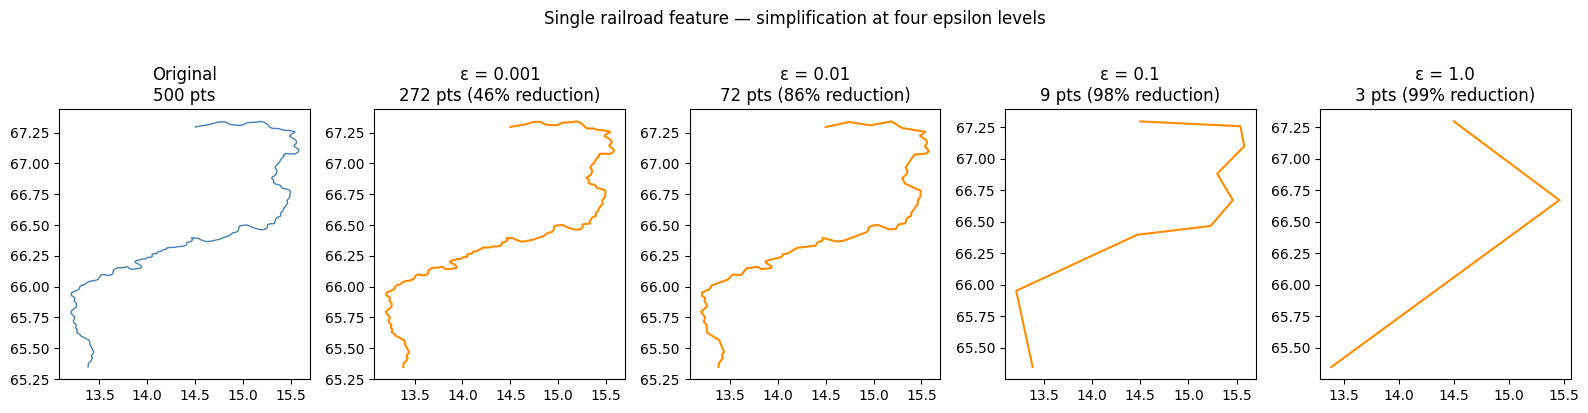

In [4]:
import matplotlib.pyplot as plt

epsilons = [0.001, 0.01, 0.1, 1.0]

fig, axes = plt.subplots(1, len(epsilons) + 1, figsize=(16, 4))

# Original
xs_o = [c[0] for c in coords]
ys_o = [c[1] for c in coords]
axes[0].plot(xs_o, ys_o, '-', color='steelblue', linewidth=1)
axes[0].set_title(f'Original\n{len(coords)} pts')

# Simplified at each epsilon
for ax, eps in zip(axes[1:], epsilons):
    simplified = douglas_peucker(coords, epsilon=eps)
    xs_s = [c[0] for c in simplified]
    ys_s = [c[1] for c in simplified]
    reduction = (1 - len(simplified) / len(coords)) * 100
    ax.plot(xs_s, ys_s, '-', color='darkorange', linewidth=1.5)
    ax.set_title(f'ε = {eps}\n{len(simplified)} pts ({reduction:.0f}% reduction)')

plt.suptitle('Single railroad feature — simplification at four epsilon levels', y=1.02)
plt.tight_layout()
plt.show()

## Measuring Reduction Across All Features

One feature is illustrative but not representative. Let's apply simplification to **all 25,000+ features** at each epsilon and measure the total coordinate count.

In [5]:
import time

original_total = sum(len(f["geometry"]["coordinates"]) for f in features)

print(f"{'Epsilon':<10} {'Total coords':>14} {'Reduction':>12} {'Time (s)':>10}")
print("-" * 50)

results = {}

for eps in [1.0, 0.1, 0.01, 0.001]:
    start_time = time.perf_counter()
    total = 0
    simplified_features = []
    for f in features:
        simplified_coords = douglas_peucker(f["geometry"]["coordinates"], eps)
        total += len(simplified_coords)
        simplified_features.append(simplified_coords)
    elapsed = time.perf_counter() - start_time
    reduction = (1 - total / original_total) * 100
    results[eps] = simplified_features
    print(f"{eps:<10} {total:>14,} {reduction:>11.1f}% {elapsed:>10.2f}")

print("-" * 50)
print(f"{'original':<10} {original_total:>14,}")

Epsilon      Total coords    Reduction   Time (s)
--------------------------------------------------
1.0                50,836        96.4%       0.68
0.1                55,513        96.0%       0.91
0.01              124,879        91.1%       2.17
0.001             441,871        68.4%       3.48
--------------------------------------------------
original        1,396,480


## Visualizing on a Map — One Epsilon at a Time

Now let's see what each level looks like rendered on an actual map.

We build a simplified `FeatureCollection` for each epsilon and display it. We use a random sample of 500 features so the notebook stays responsive.

In [8]:
import random
from ipyleaflet import Map, GeoJSON, TileLayer
import ipywidgets as widgets

random.seed(42)
sample_indices = random.sample(range(len(features)), 25000)

def make_collection(epsilon):
    sample_features = []
    for i in sample_indices:
        f = features[i]
        simplified_coords = douglas_peucker(f["geometry"]["coordinates"], epsilon)
        if len(simplified_coords) >= 2:
            sample_features.append({
                "type": "Feature",
                "properties": f["properties"],
                "geometry": {"type": "LineString", "coordinates": simplified_coords}
            })
    return {"type": "FeatureCollection", "features": sample_features}

In [20]:
# Change this value to compare levels: 1.0, 0.1, 0.01, 0.001
epsilon = 0.1

collection = make_collection(epsilon)

m = Map(center=(40.7128, -74.0060), zoom=10)
mapnik = TileLayer(url='https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png', 
                   attribution='Map data © OpenStreetMap contributors')

m = Map(center=[20, 0], zoom=2)
layer = GeoJSON(
    data=collection,
    style={"color": "#cc3300", "weight": 1, "opacity": 0.8}
)
m.add_layer(mapnik)
m.add(layer)
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

Rerun the cell above with different epsilon values and compare. At zoom=2, even epsilon=1.0 looks passable. Zoom in and the difference becomes stark.

## Comparing to Shapely on a Geographic Feature

Let's run a direct comparison on one real feature — our implementation vs. Shapely.

In [11]:
from shapely.geometry import LineString

feature = long_features[0]
coords  = feature["geometry"]["coordinates"]
epsilon = 0.01

our_result     = douglas_peucker(coords, epsilon)
shapely_line   = LineString(coords)
shapely_result = list(shapely_line.simplify(epsilon, preserve_topology=False).coords)

print(f"Original:       {len(coords)} points")
print(f"Our result:     {len(our_result)} points")
print(f"Shapely result: {len(shapely_result)} points")

Original:       500 points
Our result:     72 points
Shapely result: 71 points


The counts should be equal or within 1–2 points. Any small difference is floating-point tie-breaking in edge cases — not a logic error.

After verifying correctness here, the next module will use Shapely for the full LOD pipeline — because it is significantly faster on large datasets.

## Exercise A

Using your measured results from the table above, design the four LOD levels for the railroad project.

Fill in this table with the epsilon you would choose for each level and justify your choices:

| Level | Zoom Range | Epsilon | Reasoning |
|-------|-----------|---------|------------|
| Coarse | 1–3 | 0.1 | Though it may be a little extreme for being so zoomed out, I think the reduction is significant enough |
| Medium | 4–6 | 0.01 | The moderate level will showcase plenty of detail while still being relatively zoomed out |
| Fine | 7–10 | 0.001 | This finer level will showcase ample detail for being on a small area |
| Extra Fine | 11+ | 0.0001 | For the local level, so few points will exist within a map area that such a small epsilon is fine |

There is no single correct answer — defend your tradeoffs.

In [16]:
# Write your epsilon choices and reasoning as comments
# Your code here

coarse = 0.1
medium = 0.01
fine = 0.001
extra = .0001
table=f"""
| Level | Zoom Range | Epsilon | Reasoning |
|-------|-----------|---------|------------|
| Coarse | 1–3 | {coarse} | Though it may be a little extreme for being so zoomed out, I think the reduction is significant enough |
| Medium | 4–6 | {medium} | The moderate level will showcase plenty of detail while still being relatively zoomed out |
| Fine | 7–10 | {fine} | This finer level will showcase ample detail for being on a small area |
| Extra Fine | 11+ | {extra} | For the local level, so few points will exist within a map area that such a small epsilon is fine |
"""

print(f"{'Level':<12} {'Zoom Range':>8} {'Epsilon':>8} {'Reasoning':>9}")
print("-" * 52)

c="Coarse"
z="1-3"
r="Though it may be a little extreme for being so zoomed out, I think the reduction is significant enough"
print(f"{c:<12} {z:>8} {coarse:>8} {r:>9}")

c="Medium"
z="4-6"
r="The moderate level will showcase plenty of detail while still being relatively zoomed out"
print(f"{c:<12} {z:>8} {medium:>8} {r:>9}")

c="Fine"
z="7-10"
r="This finer level will showcase ample detail for being on a small area"
print(f"{c:<12} {z:>8} {fine:>8} {r:>9}")

c="Extra Fine"
z="11+"
r="For the local level, so few points will exist within a map area that such a small epsilon is fine"
print(f"{c:<12} {z:>8} {extra:>8} {r:>9}")


Level        Zoom Range  Epsilon Reasoning
----------------------------------------------------
Coarse            1-3      0.1 Though it may be a little extreme for being so zoomed out, I think the reduction is significant enough
Medium            4-6     0.01 The moderate level will showcase plenty of detail while still being relatively zoomed out
Fine             7-10    0.001 This finer level will showcase ample detail for being on a small area
Extra Fine        11+   0.0001 For the local level, so few points will exist within a map area that such a small epsilon is fine


## Exercise B

After simplification with `epsilon=1.0`, some features are reduced to exactly **2 points** — just a start and an end.

1. Count how many features in the full dataset are reduced to 2 points at epsilon=1.0.
2. Should we keep those 2-point features in a coarse LOD file, or discard them? Argue for one side.

In [18]:
# Count features reduced to 2 points at epsilon=1.0
# Your code here

def count_two_point_features(epsilon):
    count = 0

    for i in sample_indices:
        f = features[i]
        simplified_coords = douglas_peucker(f["geometry"]["coordinates"], epsilon)

        if len(simplified_coords) == 2:
            count += 1

    return count


# Run for epsilon = 1.0
result = count_two_point_features(1.0)
print("Features reduced to exactly 2 points:", result)


Features reduced to exactly 2 points: 24990


Yes we should absolutely keep these. With nearly 25,000 features that were reduced, we're reducing pretty much the entire dataset, so removing these would get rid of significant amounts of data.

## Check Your Understanding

Our implementation uses coordinates in **degrees** (longitude, latitude). Shapely's `simplify()` also uses whatever units the coordinates are in.

An epsilon of `0.1` means something different in degrees near the equator vs. near the poles.

Why? And does this matter for our LOD pipeline? Write a short explanation (3–5 sentences) as a comment or markdown.

---

An epsilon measured in degrees represents angular distance, not physical distance, and the real-world spacing between degrees of longitude changes with latitude. Near the equator, one degree of longitude corresponds to a much larger distance than it does near the poles, where lines of longitude converge. This means the same epsilon value will simplify geometries much more at higher latitudes than at lower ones. According to ChatGPT, "for a LOD pipeline, this matters because it introduces geographic inconsistency in simplification quality. To avoid this, simplification is usually done in a projected coordinate system (meters) or with a geodesic-aware method."

## Next

In [Module 02 — LOD Generation](../02-LOD_Generation/README.md), we apply these epsilon choices to all 25,000+ features and write the four output files that power the rest of the project.